In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# ══════════════════════════════════════════════════════════════
# 0. CONFIG
# ══════════════════════════════════════════════════════════════

TRAIN_PATH   = "/Users/a../Desktop/ADSP31006_TS/Project/data/model/ercot_train_2018_2023.csv"
VAL_PATH     = "/Users/a../Desktop/ADSP31006_TS/Project/data/model/ercot_validate_2024.csv"
TEST_PATH    = "/Users/a../Desktop/ADSP31006_TS/Project/data/model/ercot_test_2025.csv"
WEATHER_PATH = "/Users/a../Desktop/ADSP31006_TS/Project/data/model/test_ercot_weather_forecasts_2025.csv"

ZONES        = ['COAST', 'EAST', 'FWEST', 'NORTH', 'NCENT', 'SOUTH', 'SCENT', 'WEST']
ZONE_TARGETS = [f'{z}_load_mw' for z in ZONES]
TOTAL_TARGET = 'ERCOT_total_load_mw'
HORIZONS     = list(range(1, 73))

XGB_PARAMS = dict(
    n_estimators          = 1000,
    learning_rate         = 0.02,
    max_depth             = 5,
    subsample             = 0.7,
    colsample_bytree      = 0.7,
    min_child_weight      = 10,
    gamma                 = 0.2,
    reg_alpha             = 0.5,
    reg_lambda            = 2.0,
    random_state          = 42,
    n_jobs                = -1,
    tree_method           = 'hist',
    early_stopping_rounds = 30,
    eval_metric           = 'rmse',
)


In [3]:
# ══════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════

print("=" * 62)
print("  ERCOT XGBoost — Zone-Level Forecasting Pipeline")
print("=" * 62)

train = pd.read_csv(TRAIN_PATH,   parse_dates=['datetime'])
val   = pd.read_csv(VAL_PATH,     parse_dates=['datetime'])
test  = pd.read_csv(TEST_PATH,    parse_dates=['datetime'])
wfc   = pd.read_csv(WEATHER_PATH, parse_dates=['datetime'])

for df in [train, val, test, wfc]:
    df.sort_values('datetime', inplace=True)
    df.reset_index(drop=True, inplace=True)

# Strip timezone (CSVs stored as UTC-aware)
for df in [train, val, test, wfc]:
    if df['datetime'].dt.tz is not None:
        df['datetime'] = df['datetime'].dt.tz_convert(None)

print(f"  Train : {train['datetime'].min().date()} -> {train['datetime'].max().date()}  ({len(train):>7,} rows)")
print(f"  Val   : {val['datetime'].min().date()}   -> {val['datetime'].max().date()}   ({len(val):>7,} rows)")
print(f"  Test  : {test['datetime'].min().date()}   -> {test['datetime'].max().date()}   ({len(test):>7,} rows)")
print(f"  Wfc   : {wfc['datetime'].min().date()}    -> {wfc['datetime'].max().date()}   ({len(wfc):>7,} rows)")


  ERCOT XGBoost — Zone-Level Forecasting Pipeline
  Train : 2018-01-01 -> 2023-12-31  ( 52,584 rows)
  Val   : 2024-01-01   -> 2024-12-31   (  8,784 rows)
  Test  : 2025-01-01   -> 2025-12-31   (  8,760 rows)
  Wfc   : 2025-01-01    -> 2025-12-31   (  8,760 rows)


In [4]:
# ══════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════

def add_weather_features(df):
    TEMP  = [f'{z}_temperature_f'         for z in ZONES]
    HI    = [f'{z}_heat_index_f'          for z in ZONES]
    WIND  = [f'{z}_wind_speed_mph'        for z in ZONES]
    SOLAR = [f'{z}_solar_radiation_wm2'   for z in ZONES]
    df['avg_temp_f']         = df[TEMP].mean(axis=1)
    df['max_temp_f']         = df[TEMP].max(axis=1)
    df['min_temp_f']         = df[TEMP].min(axis=1)
    df['avg_heat_index_f']   = df[HI].mean(axis=1)
    df['avg_wind_speed_mph'] = df[WIND].mean(axis=1)
    df['max_wind_speed_mph'] = df[WIND].max(axis=1)
    df['avg_solar_wm2']      = df[SOLAR].mean(axis=1)
    df['temp_sq']            = df['avg_temp_f'] ** 2
    df['heat_index_sq']      = df['avg_heat_index_f'] ** 2
    df['cooling_degree']     = np.maximum(0, df['avg_temp_f'] - 65)
    df['heating_degree']     = np.maximum(0, 65 - df['avg_temp_f'])
    df['extreme_cold']       = (df['avg_temp_f'] < 32).astype(int)
    df['extreme_heat']       = (df['avg_temp_f'] > 95).astype(int)
    return df


def add_calendar_features(df):
    df['is_peak_hour']    = df['hour'].between(14, 20).astype(int)
    df['is_morning_ramp'] = df['hour'].between(6,   9).astype(int)
    df['season']          = df['month'].map({
        12:0, 1:0, 2:0, 3:1, 4:1, 5:1,
         6:2, 7:2, 8:2, 9:3,10:3,11:3
    })
    origin = pd.Timestamp('2018-01-01')
    df['trend'] = (df['datetime'] - origin).dt.total_seconds() / 3600
    return df


def add_zone_lag_features(df, zone):
    """Lag + rolling features for one zone; columns prefixed with zone name."""
    t = df[f'{zone}_load_mw']
    z = zone
    df[f'{z}_lag_24h']       = t.shift(24)
    df[f'{z}_lag_48h']       = t.shift(48)
    df[f'{z}_lag_72h']       = t.shift(72)
    df[f'{z}_lag_168h']      = t.shift(168)
    df[f'{z}_lag_336h']      = t.shift(336)
    df[f'{z}_lag_504h']      = t.shift(504)
    df[f'{z}_lag_672h']      = t.shift(672)
    df[f'{z}_avg4w']         = (t.shift(168) + t.shift(336) +
                                 t.shift(504) + t.shift(672)) / 4
    df[f'{z}_roll24_mean']   = t.shift(1).rolling(24).mean()
    df[f'{z}_roll24_std']    = t.shift(1).rolling(24).std()
    df[f'{z}_roll168_mean']  = t.shift(1).rolling(168).mean()
    df[f'{z}_roll168_std']   = t.shift(1).rolling(168).std()
    return df


print("\n[1/5] Engineering features...")
for df in [train, val, test]:
    df = add_weather_features(df)
    df = add_calendar_features(df)
    for z in ZONES:
        df = add_zone_lag_features(df, z)

wfc = add_weather_features(wfc)
wfc = add_calendar_features(wfc)
# wfc has no load columns — zone lags filled at inference time



[1/5] Engineering features...


In [5]:
# ══════════════════════════════════════════════════════════════
# 3. FEATURE LISTS
# ══════════════════════════════════════════════════════════════

ZONE_WEATHER_ALL = (
    [f'{z}_temperature_f'         for z in ZONES] +
    [f'{z}_heat_index_f'          for z in ZONES] +
    [f'{z}_wind_speed_mph'        for z in ZONES] +
    [f'{z}_solar_radiation_wm2'   for z in ZONES] +
    [f'{z}_relative_humidity_pct' for z in ZONES]
)

AGG_WEATHER = [
    'avg_temp_f', 'max_temp_f', 'min_temp_f',
    'avg_heat_index_f', 'avg_wind_speed_mph', 'max_wind_speed_mph', 'avg_solar_wm2',
    'temp_sq', 'heat_index_sq', 'cooling_degree', 'heating_degree',
    'extreme_cold', 'extreme_heat',
]

CALENDAR = [
    'hour', 'day_of_week', 'month', 'year',
    'is_weekend', 'is_holiday',
    'is_peak_hour', 'is_morning_ramp', 'season', 'trend',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
]

SHARED_CANDIDATES = ZONE_WEATHER_ALL + AGG_WEATHER + CALENDAR


def zone_lag_cols(zone):
    z = zone
    return [
        f'{z}_lag_24h',  f'{z}_lag_48h',  f'{z}_lag_72h',  f'{z}_lag_168h',
        f'{z}_lag_336h', f'{z}_lag_504h', f'{z}_lag_672h', f'{z}_avg4w',
        f'{z}_roll24_mean', f'{z}_roll24_std',
        f'{z}_roll168_mean', f'{z}_roll168_std',
    ]


def get_features(zone, df):
    """All features present in df for a given zone."""
    return [f for f in SHARED_CANDIDATES + zone_lag_cols(zone) if f in df.columns]


print(f"    Features per zone model : {len(get_features('COAST', train))}")
print(f"    Total models to train   : {len(ZONES)} zones × {len(HORIZONS)} horizons = {len(ZONES)*len(HORIZONS)}")

    Features per zone model : 81
    Total models to train   : 8 zones × 72 horizons = 576


In [6]:
# ══════════════════════════════════════════════════════════════
# 4. TRAINING  (576 models: zone × horizon)
# ══════════════════════════════════════════════════════════════

def make_Xy(df, zone, h, features):
    d = df.copy()
    d['_target'] = d[f'{zone}_load_mw'].shift(-h)
    d = d.dropna(subset=['_target'] + features)
    return d[features], d['_target']


print("\n[2/5] Training 576 XGBoost models (8 zones × 72 horizons)...\n")

models = {z: {} for z in ZONES}

for z in ZONES:
    feats = get_features(z, train)
    print(f"  Zone {z} ({len(feats)} features)...", end='', flush=True)
    for h in HORIZONS:
        X_tr, y_tr = make_Xy(train, z, h, feats)
        X_va, y_va = make_Xy(val,   z, h, feats)
        if len(X_va) < 24:
            X_va, y_va = X_tr.iloc[-500:], y_tr.iloc[-500:]
        m = XGBRegressor(**XGB_PARAMS)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        models[z][h] = m
    print(f"  done (best_iter h=24: {models[z][24].best_iteration})")

print("\n  All 576 models trained.")



[2/5] Training 576 XGBoost models (8 zones × 72 horizons)...

  Zone COAST (81 features)...  done (best_iter h=24: 440)
  Zone EAST (81 features)...  done (best_iter h=24: 577)
  Zone FWEST (81 features)...  done (best_iter h=24: 414)
  Zone NORTH (81 features)...  done (best_iter h=24: 246)
  Zone NCENT (81 features)...  done (best_iter h=24: 837)
  Zone SOUTH (81 features)...  done (best_iter h=24: 331)
  Zone SCENT (81 features)...  done (best_iter h=24: 649)
  Zone WEST (81 features)...  done (best_iter h=24: 642)

  All 576 models trained.


In [7]:
# ══════════════════════════════════════════════════════════════
# 5. EVALUATION
# ══════════════════════════════════════════════════════════════

def mape(y_true, y_pred):
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred))
                          / np.array(y_true))) * 100


def evaluate_all(df, models, label):
    """
    Per horizon h: predict all 8 zones → sum → compare to ERCOT total.
    Also computes per-zone MAPE at h=24.
    """
    mae_list, rmse_list, mape_list = [], [], []
    zone_mape_24 = {}

    for h in HORIZONS:
        # Align all zones on a common valid index
        ref = df.copy()
        ref['_total_target'] = ref[TOTAL_TARGET].shift(-h)
        ref = ref.dropna(subset=['_total_target'])

        zone_preds = {}
        for z in ZONES:
            feats = get_features(z, df)
            d = df.copy()
            d['_target'] = d[f'{z}_load_mw'].shift(-h)
            d = d.dropna(subset=['_target'] + feats)
            pred = models[z][h].predict(d[feats])
            zone_preds[z] = pd.Series(pred, index=d.index)
            if h == 24:
                zone_mape_24[z] = mape(d['_target'].values, pred)

        # Common index across all zones + total
        common = ref.index
        for z in ZONES:
            common = common.intersection(zone_preds[z].index)

        total_pred   = sum(zone_preds[z][common] for z in ZONES)
        total_actual = ref.loc[common, '_total_target']

        mae_list.append(mean_absolute_error(total_actual, total_pred))
        rmse_list.append(np.sqrt(mean_squared_error(total_actual, total_pred)))
        mape_list.append(mape(total_actual.values, total_pred.values))

    print(f"\n{'─'*58}")
    print(f"  {label}  —  ERCOT Total (sum of 8 zone forecasts)")
    print(f"{'─'*58}")
    print(f"  {'Horizon':<14} {'MAE (MW)':>10} {'RMSE (MW)':>12} {'MAPE (%)':>10}")
    for h_show in [6, 12, 24, 48, 72]:
        i = h_show - 1
        print(f"  {h_show}h ahead{'':<6} "
              f"{mae_list[i]:>10,.0f} {rmse_list[i]:>12,.0f} {mape_list[i]:>10.2f}")
    print(f"  {'Mean 1–72h':<14} "
          f"{np.nanmean(mae_list):>10,.0f} "
          f"{np.nanmean(rmse_list):>12,.0f} "
          f"{np.nanmean(mape_list):>10.2f}")
    print(f"\n  Per-Zone MAPE at 24h:")
    for z, mp in zone_mape_24.items():
        print(f"    {z:<8} {mp:>7.2f}%")

    return mae_list, rmse_list, mape_list, zone_mape_24


print("\n[3/5] Evaluating models...")
val_mae,  val_rmse,  val_mape_list,  val_zone_mape  = evaluate_all(val,  models, "Validation (2024)")
test_mae, test_rmse, test_mape_list, test_zone_mape = evaluate_all(test, models, "Test (2025)")

# Feature importance (24h model per zone)
imp_by_zone = {}
print("\n  Top 5 Features per Zone (24h model):")
for z in ZONES:
    feats = get_features(z, train)
    imp = pd.DataFrame({'feature': feats,
                         'importance': models[z][24].feature_importances_}
                       ).sort_values('importance', ascending=False).reset_index(drop=True)
    imp_by_zone[z] = imp
    print(f"    {z:<8}: {', '.join(imp['feature'].head(5).tolist())}")


[3/5] Evaluating models...

──────────────────────────────────────────────────────────
  Validation (2024)  —  ERCOT Total (sum of 8 zone forecasts)
──────────────────────────────────────────────────────────
  Horizon          MAE (MW)    RMSE (MW)   MAPE (%)
  6h ahead            1,552        2,044       2.92
  12h ahead            1,799        2,462       3.35
  24h ahead            2,236        2,930       4.18
  48h ahead            2,917        3,737       5.41
  72h ahead            3,301        4,209       6.10
  Mean 1–72h          2,539        3,306       4.71

  Per-Zone MAPE at 24h:
    COAST       5.32%
    EAST        6.02%
    FWEST       7.10%
    NORTH      11.20%
    NCENT       5.88%
    SOUTH       5.38%
    SCENT       5.10%
    WEST        4.82%

──────────────────────────────────────────────────────────
  Test (2025)  —  ERCOT Total (sum of 8 zone forecasts)
──────────────────────────────────────────────────────────
  Horizon          MAE (MW)    RMSE (MW)   MAPE

In [8]:
def build_feature_row(dt, zone, wfc_indexed, zone_histories, features):
    """
    dt            : tz-naive pd.Timestamp
    zone          : e.g. 'COAST'
    wfc_indexed   : weather forecast DataFrame indexed by datetime
    zone_histories: dict {zone: pd.Series(load indexed by datetime)}
                    — each zone's history grows as predictions are made
    features      : ordered feature list for this zone
    """
    row     = {}
    history = zone_histories[zone]

    # Weather
    if dt in wfc_indexed.index:
        w = wfc_indexed.loc[dt]
    else:
        idx = wfc_indexed.index.get_indexer([dt], method='nearest')[0]
        w   = wfc_indexed.iloc[idx]
    for col in wfc_indexed.columns:
        row[col] = w[col]

    # Aggregate weather
    def safe(lst): return [v for v in lst if not np.isnan(v)]
    t_ = safe([row.get(f'{z}_temperature_f',       np.nan) for z in ZONES])
    h_ = safe([row.get(f'{z}_heat_index_f',         np.nan) for z in ZONES])
    w_ = safe([row.get(f'{z}_wind_speed_mph',       np.nan) for z in ZONES])
    s_ = safe([row.get(f'{z}_solar_radiation_wm2',  np.nan) for z in ZONES])
    avg_t = np.mean(t_) if t_ else 65.0
    avg_h = np.mean(h_) if h_ else 65.0
    row.update({
        'avg_temp_f': avg_t, 'max_temp_f': max(t_) if t_ else 65.0,
        'min_temp_f': min(t_) if t_ else 65.0,
        'avg_heat_index_f': avg_h,
        'avg_wind_speed_mph': np.mean(w_) if w_ else 10.0,
        'max_wind_speed_mph': max(w_) if w_ else 15.0,
        'avg_solar_wm2': np.mean(s_) if s_ else 0.0,
        'temp_sq': avg_t**2, 'heat_index_sq': avg_h**2,
        'cooling_degree': max(0, avg_t-65), 'heating_degree': max(0, 65-avg_t),
        'extreme_cold': int(avg_t < 32), 'extreme_heat': int(avg_t > 95),
    })

    # Calendar
    row.update({
        'hour': dt.hour, 'day_of_week': dt.dayofweek,
        'month': dt.month, 'year': dt.year,
        'is_weekend': int(dt.dayofweek >= 5),
        'is_peak_hour': int(14 <= dt.hour <= 20),
        'is_morning_ramp': int(6 <= dt.hour <= 9),
        'season': {12:0,1:0,2:0,3:1,4:1,5:1,6:2,7:2,8:2,9:3,10:3,11:3}[dt.month],
        'trend': (dt - pd.Timestamp('2018-01-01')).total_seconds() / 3600,
        'hour_sin':  np.sin(2*np.pi*dt.hour/24),
        'hour_cos':  np.cos(2*np.pi*dt.hour/24),
        'month_sin': np.sin(2*np.pi*dt.month/12),
        'month_cos': np.cos(2*np.pi*dt.month/12),
        'dow_sin':   np.sin(2*np.pi*dt.dayofweek/7),
        'dow_cos':   np.cos(2*np.pi*dt.dayofweek/7),
        'is_holiday': int(dt.normalize() in pd.to_datetime([
            '2025-01-01','2025-01-20','2025-02-17','2025-05-26',
            '2025-06-19','2025-07-04','2025-09-01','2025-10-13',
            '2025-11-11','2025-11-27','2025-12-25',
        ])),
    })

    # Zone-specific lags
    def lag(h_lag):
        t2 = dt - pd.Timedelta(hours=h_lag)
        if t2 in history.index:
            return float(history.loc[t2])
        past = history[history.index <= t2]
        return float(past.iloc[-1]) if len(past) > 0 else float(history.mean())

    def roll_stats(window_h):
        # Slice history between (dt - window_h hours) and (dt - 1 hour) inclusive
        t_end   = dt - pd.Timedelta(hours=1)
        t_start = dt - pd.Timedelta(hours=window_h)
        vals    = history.loc[(history.index >= t_start) & (history.index <= t_end)]
        if len(vals) == 0:
            return float(history.mean()), float(history.std())
        return float(vals.mean()), float(vals.std())

    z = zone
    m24, s24   = roll_stats(24)
    m168, s168 = roll_stats(168)
    row.update({
        f'{z}_lag_24h':  lag(24),  f'{z}_lag_48h':  lag(48),
        f'{z}_lag_72h':  lag(72),  f'{z}_lag_168h': lag(168),
        f'{z}_lag_336h': lag(336), f'{z}_lag_504h': lag(504),
        f'{z}_lag_672h': lag(672),
        f'{z}_avg4w':    np.mean([lag(168), lag(336), lag(504), lag(672)]),
        f'{z}_roll24_mean':  m24,  f'{z}_roll24_std':  s24,
        f'{z}_roll168_mean': m168, f'{z}_roll168_std': s168,
    })

    X = pd.DataFrame([row])
    for f in features:
        if f not in X.columns:
            X[f] = 0.0
    return X[features]



In [9]:
# ══════════════════════════════════════════════════════════════
# 7. DIRECT ROLLING FORECAST  (re-issue every 24h)
# ══════════════════════════════════════════════════════════════

def direct_rolling_forecast(start, end, wfc_indexed, zone_histories_seed,
                             models, reforecast_every_h=24):
    """
    Re-issues a 72h direct forecast every `reforecast_every_h` hours.

    Lag fix: within each 72h issue window we maintain `temp_hists` — a
    per-zone history that is extended immediately after each h-step
    prediction.  This means when we predict h=48 and need lag_24h, the
    value at (issue_dt+24) is already present in temp_hists from the
    h=24 step.  Only the first `reforecast_every_h` hours of each window
    are committed to the persistent `zone_hists` so that the next issue
    window starts from clean confirmed predictions.
    """
    all_hours   = pd.date_range(start, end, freq='h')
    zone_preds  = {z: pd.Series(np.nan, index=all_hours) for z in ZONES}
    zone_hists  = {z: zone_histories_seed[z].copy()       for z in ZONES}
    issue_times = pd.date_range(start, end, freq=f'{reforecast_every_h}h')

    for issue_dt in issue_times:
        # temp_hists starts as a copy of committed history and grows
        # step-by-step as we predict h=1, 2, ..., 72 in order
        temp_hists = {z: zone_hists[z].copy() for z in ZONES}

        for h in range(1, 73):
            target_dt = issue_dt + pd.Timedelta(hours=h)
            if target_dt > end:
                break

            for z in ZONES:
                # If a more-recent issue window already set this slot, skip
                if not np.isnan(zone_preds[z].get(target_dt, np.nan)):
                    # Still add it to temp_hists so later h-steps can use it
                    temp_hists[z][target_dt] = zone_preds[z][target_dt]
                    continue

                feats = get_features(z, train)
                # Use temp_hists so lag_24h at h=48 correctly reads h=24's prediction
                X    = build_feature_row(target_dt, z, wfc_indexed, temp_hists, feats)
                pred = float(models[z][min(h, max(models[z].keys()))].predict(X)[0])
                pred = max(pred, 500)

                zone_preds[z][target_dt]  = pred
                temp_hists[z][target_dt]  = pred   # immediately available for h+1, h+2, ...

        # Commit only the first reforecast_every_h hours to persistent history
        # (the "confirmed" window that the next issue will use as real lags)
        commit_end = issue_dt + pd.Timedelta(hours=reforecast_every_h)
        for dt in pd.date_range(issue_dt + pd.Timedelta(hours=1), commit_end, freq='h'):
            for z in ZONES:
                if dt in zone_preds[z].index and not np.isnan(zone_preds[z][dt]):
                    zone_hists[z][dt] = zone_preds[z][dt]

    total = sum(zone_preds[z] for z in ZONES).dropna().sort_index()
    return zone_preds, total, zone_hists

In [10]:
# ══════════════════════════════════════════════════════════════
# 8. RUN 3-MONTH FORECASTS  (direct rolling, all 3 quarters)
# ══════════════════════════════════════════════════════════════
# Weather forecast covers all of 2025, so we run direct rolling
# continuously across Q1 → Q2 → Q3.
#
# How it works:
#   - Every 24h a fresh 72h direct forecast is issued per zone
#   - The committed 24h window is added to each zone's history
#   - The next issue window picks up those predictions as lags
#   - This chains Q1 → Q2 → Q3 seamlessly in one long pass

print("\n[4/5] Running 3-month direct rolling forecasts...")

wfc_idx = wfc.set_index('datetime')

# ── Sanity check: verify weather coverage and lag seed ────────
print("\n  Diagnostics:")
print(f"    wfc rows          : {len(wfc_idx):,}")
print(f"    wfc date range    : {wfc_idx.index.min().date()} → {wfc_idx.index.max().date()}")
# Check temperature at Jan, Apr, Jul, Oct to confirm seasonal variation
temp_cols = [f'{z}_temperature_f' for z in ZONES]
for check_dt in ['2025-01-15 12:00', '2025-04-15 12:00',
                  '2025-07-15 12:00', '2025-10-15 12:00']:
    dt = pd.Timestamp(check_dt)
    if dt in wfc_idx.index:
        avg_t = wfc_idx.loc[dt, temp_cols].mean()
        print(f"    {check_dt} avg temp : {avg_t:.1f}°F  found")
    else:
        idx   = wfc_idx.index.get_indexer([dt], method='nearest')[0]
        avg_t = wfc_idx.iloc[idx][temp_cols].mean()
        nearest = wfc_idx.index[idx]
        print(f"    {check_dt} avg temp : {avg_t:.1f}°F  ⚠️  NOT FOUND, used {nearest}")

# Check lag seed coverage
for z in ['COAST', 'NCENT']:
    s = pd.concat([train, val]).set_index('datetime')[f'{z}_load_mw']
    print(f"    {z} seed: {s.index.min().date()} → {s.index.max().date()}  ({len(s):,} rows)")
print()

# Seed zone histories from train + val only (end of 2024).
# test (2025) is what we are forecasting — including it would be data leakage.
seed_data = pd.concat([train, val]).sort_values('datetime')
zone_histories_seed = {
    z: seed_data.set_index('datetime')[f'{z}_load_mw']
    for z in ZONES
}

# Quarter boundaries
Q1_START = pd.Timestamp('2025-01-01');  Q1_END = pd.Timestamp('2025-03-31 23:00')
Q2_START = pd.Timestamp('2025-04-01');  Q2_END = pd.Timestamp('2025-06-30 23:00')
Q3_START = pd.Timestamp('2025-07-01');  Q3_END = pd.Timestamp('2025-09-30 23:00')
Q4_START = pd.Timestamp('2025-10-01');  Q4_END = pd.Timestamp('2025-12-31 23:00')

# Run direct rolling pass per quarter, chaining histories forward.
print(f"\n  Q1: {Q1_START.date()} → {Q1_END.date()}")
dir_zone_q1, direct_total_q1, hist_after_q1 = direct_rolling_forecast(
    Q1_START, Q1_END, wfc_idx, zone_histories_seed, models, reforecast_every_h=24
)
print(f"    ERCOT: Avg={direct_total_q1.mean():,.0f}  "
      f"Min={direct_total_q1.min():,.0f}  Max={direct_total_q1.max():,.0f} MW")

print(f"\n  Q2: {Q2_START.date()} → {Q2_END.date()}")
dir_zone_q2, direct_total_q2, hist_after_q2 = direct_rolling_forecast(
    Q2_START, Q2_END, wfc_idx, hist_after_q1, models, reforecast_every_h=24
)
print(f"    ERCOT: Avg={direct_total_q2.mean():,.0f}  "
      f"Min={direct_total_q2.min():,.0f}  Max={direct_total_q2.max():,.0f} MW")

print(f"\n  Q3: {Q3_START.date()} → {Q3_END.date()}")
dir_zone_q3, direct_total_q3, hist_after_q3 = direct_rolling_forecast(
    Q3_START, Q3_END, wfc_idx, hist_after_q2, models, reforecast_every_h=24
)
print(f"    ERCOT: Avg={direct_total_q3.mean():,.0f}  "
      f"Min={direct_total_q3.min():,.0f}  Max={direct_total_q3.max():,.0f} MW")

print(f"\n  Q4: {Q4_START.date()} → {Q4_END.date()}")
dir_zone_q4, direct_total_q4, hist_after_q4 = direct_rolling_forecast(
    Q4_START, Q4_END, wfc_idx, hist_after_q3, models, reforecast_every_h=24
)
print(f"    ERCOT: Avg={direct_total_q4.mean():,.0f}  "
      f"Min={direct_total_q4.min():,.0f}  Max={direct_total_q4.max():,.0f} MW")

# Combine all quarters
direct_total_all = pd.concat([
    direct_total_q1, direct_total_q2, direct_total_q3, direct_total_q4
]).sort_index()
dir_zone_all = {
    z: pd.concat([dir_zone_q1[z], dir_zone_q2[z],
                  dir_zone_q3[z], dir_zone_q4[z]]).sort_index()
    for z in ZONES
}

# ── Evaluate Q1 vs actuals (only quarter with test data) ──────
test_total = test.set_index('datetime')[TOTAL_TARGET]
common_q1  = direct_total_q1.index.intersection(test_total.index)

def metrics(a, p):
    return (mean_absolute_error(a, p),
            np.sqrt(mean_squared_error(a, p)),
            mape(a.values, p.values))

if len(common_q1) > 0:
    m_q1 = metrics(test_total[common_q1], direct_total_q1[common_q1])
    print(f"\n{'─'*58}")
    print(f"  Q1 2025 Direct Forecast vs. Actuals  ({len(common_q1):,} hours)")
    print(f"{'─'*58}")
    print(f"  {'MAE (MW)':>10} {'RMSE (MW)':>12} {'MAPE (%)':>10}")
    print(f"  {m_q1[0]:>10,.0f} {m_q1[1]:>12,.0f} {m_q1[2]:>10.2f}")

    print(f"\n  Per-Zone Q1 MAPE (Direct):")
    test_z = test.set_index('datetime')
    for z in ZONES:
        z_common = dir_zone_q1[z].dropna().index.intersection(test_z.index)
        if len(z_common) > 0:
            zm = mape(test_z.loc[z_common, f'{z}_load_mw'].values,
                      dir_zone_q1[z][z_common].values)
            print(f"    {z:<8} {zm:>7.2f}%")
else:
    print("\n  (No test actuals overlap Q1 — skipping Q1 eval)")



[4/5] Running 3-month direct rolling forecasts...

  Diagnostics:
    wfc rows          : 8,760
    wfc date range    : 2025-01-01 → 2025-12-31
    2025-01-15 12:00 avg temp : 60.1°F  found
    2025-04-15 12:00 avg temp : 74.3°F  found
    2025-07-15 12:00 avg temp : 93.8°F  found
    2025-10-15 12:00 avg temp : 74.6°F  found
    COAST seed: 2018-01-01 → 2024-12-31  (61,368 rows)
    NCENT seed: 2018-01-01 → 2024-12-31  (61,368 rows)


  Q1: 2025-01-01 → 2025-03-31
    ERCOT: Avg=45,042  Min=37,321  Max=50,720 MW

  Q2: 2025-04-01 → 2025-06-30
    ERCOT: Avg=54,501  Min=37,139  Max=77,776 MW

  Q3: 2025-07-01 → 2025-09-30
    ERCOT: Avg=62,849  Min=44,370  Max=78,694 MW

  Q4: 2025-10-01 → 2025-12-31
    ERCOT: Avg=45,949  Min=37,594  Max=67,353 MW

──────────────────────────────────────────────────────────
  Q1 2025 Direct Forecast vs. Actuals  (2,159 hours)
──────────────────────────────────────────────────────────
    MAE (MW)    RMSE (MW)   MAPE (%)
       7,098        9,779      

In [11]:
# ══════════════════════════════════════════════════════════════
# 9. SAVE OUTPUTS
# ══════════════════════════════════════════════════════════════

metrics_df = pd.DataFrame({
    'horizon_h': HORIZONS,
    'val_MAE':   val_mae,   'val_RMSE':  val_rmse,  'val_MAPE':  val_mape_list,
    'test_MAE':  test_mae,  'test_RMSE': test_rmse, 'test_MAPE': test_mape_list,
})
metrics_df.to_csv('xgb_metrics_by_horizon.csv', index=False)

# Full year direct forecast — build by merging zone series on datetime
# (avoids length mismatch from concat producing different row counts per zone)
full_df = pd.DataFrame({'datetime': direct_total_all.index,
                         'ercot_total_mw': direct_total_all.values})
for z in ZONES:
    zone_df = dir_zone_all[z].rename(f'{z}_mw').reset_index()
    zone_df.columns = ['datetime', f'{z}_mw']
    full_df = full_df.merge(zone_df, on='datetime', how='left')
if len(common_q1) > 0:
    full_df = full_df.merge(
        test_total.reset_index().rename(columns={TOTAL_TARGET: 'actual_total_mw'}),
        on='datetime', how='left')
full_df.to_csv('xgb_fullyear_direct_forecast.csv', index=False)

print("\n  Saved: xgb_metrics_by_horizon.csv")
print("  Saved: xgb_fullyear_direct_forecast.csv")



  Saved: xgb_metrics_by_horizon.csv
  Saved: xgb_fullyear_direct_forecast.csv



[5/5] Generating plots...


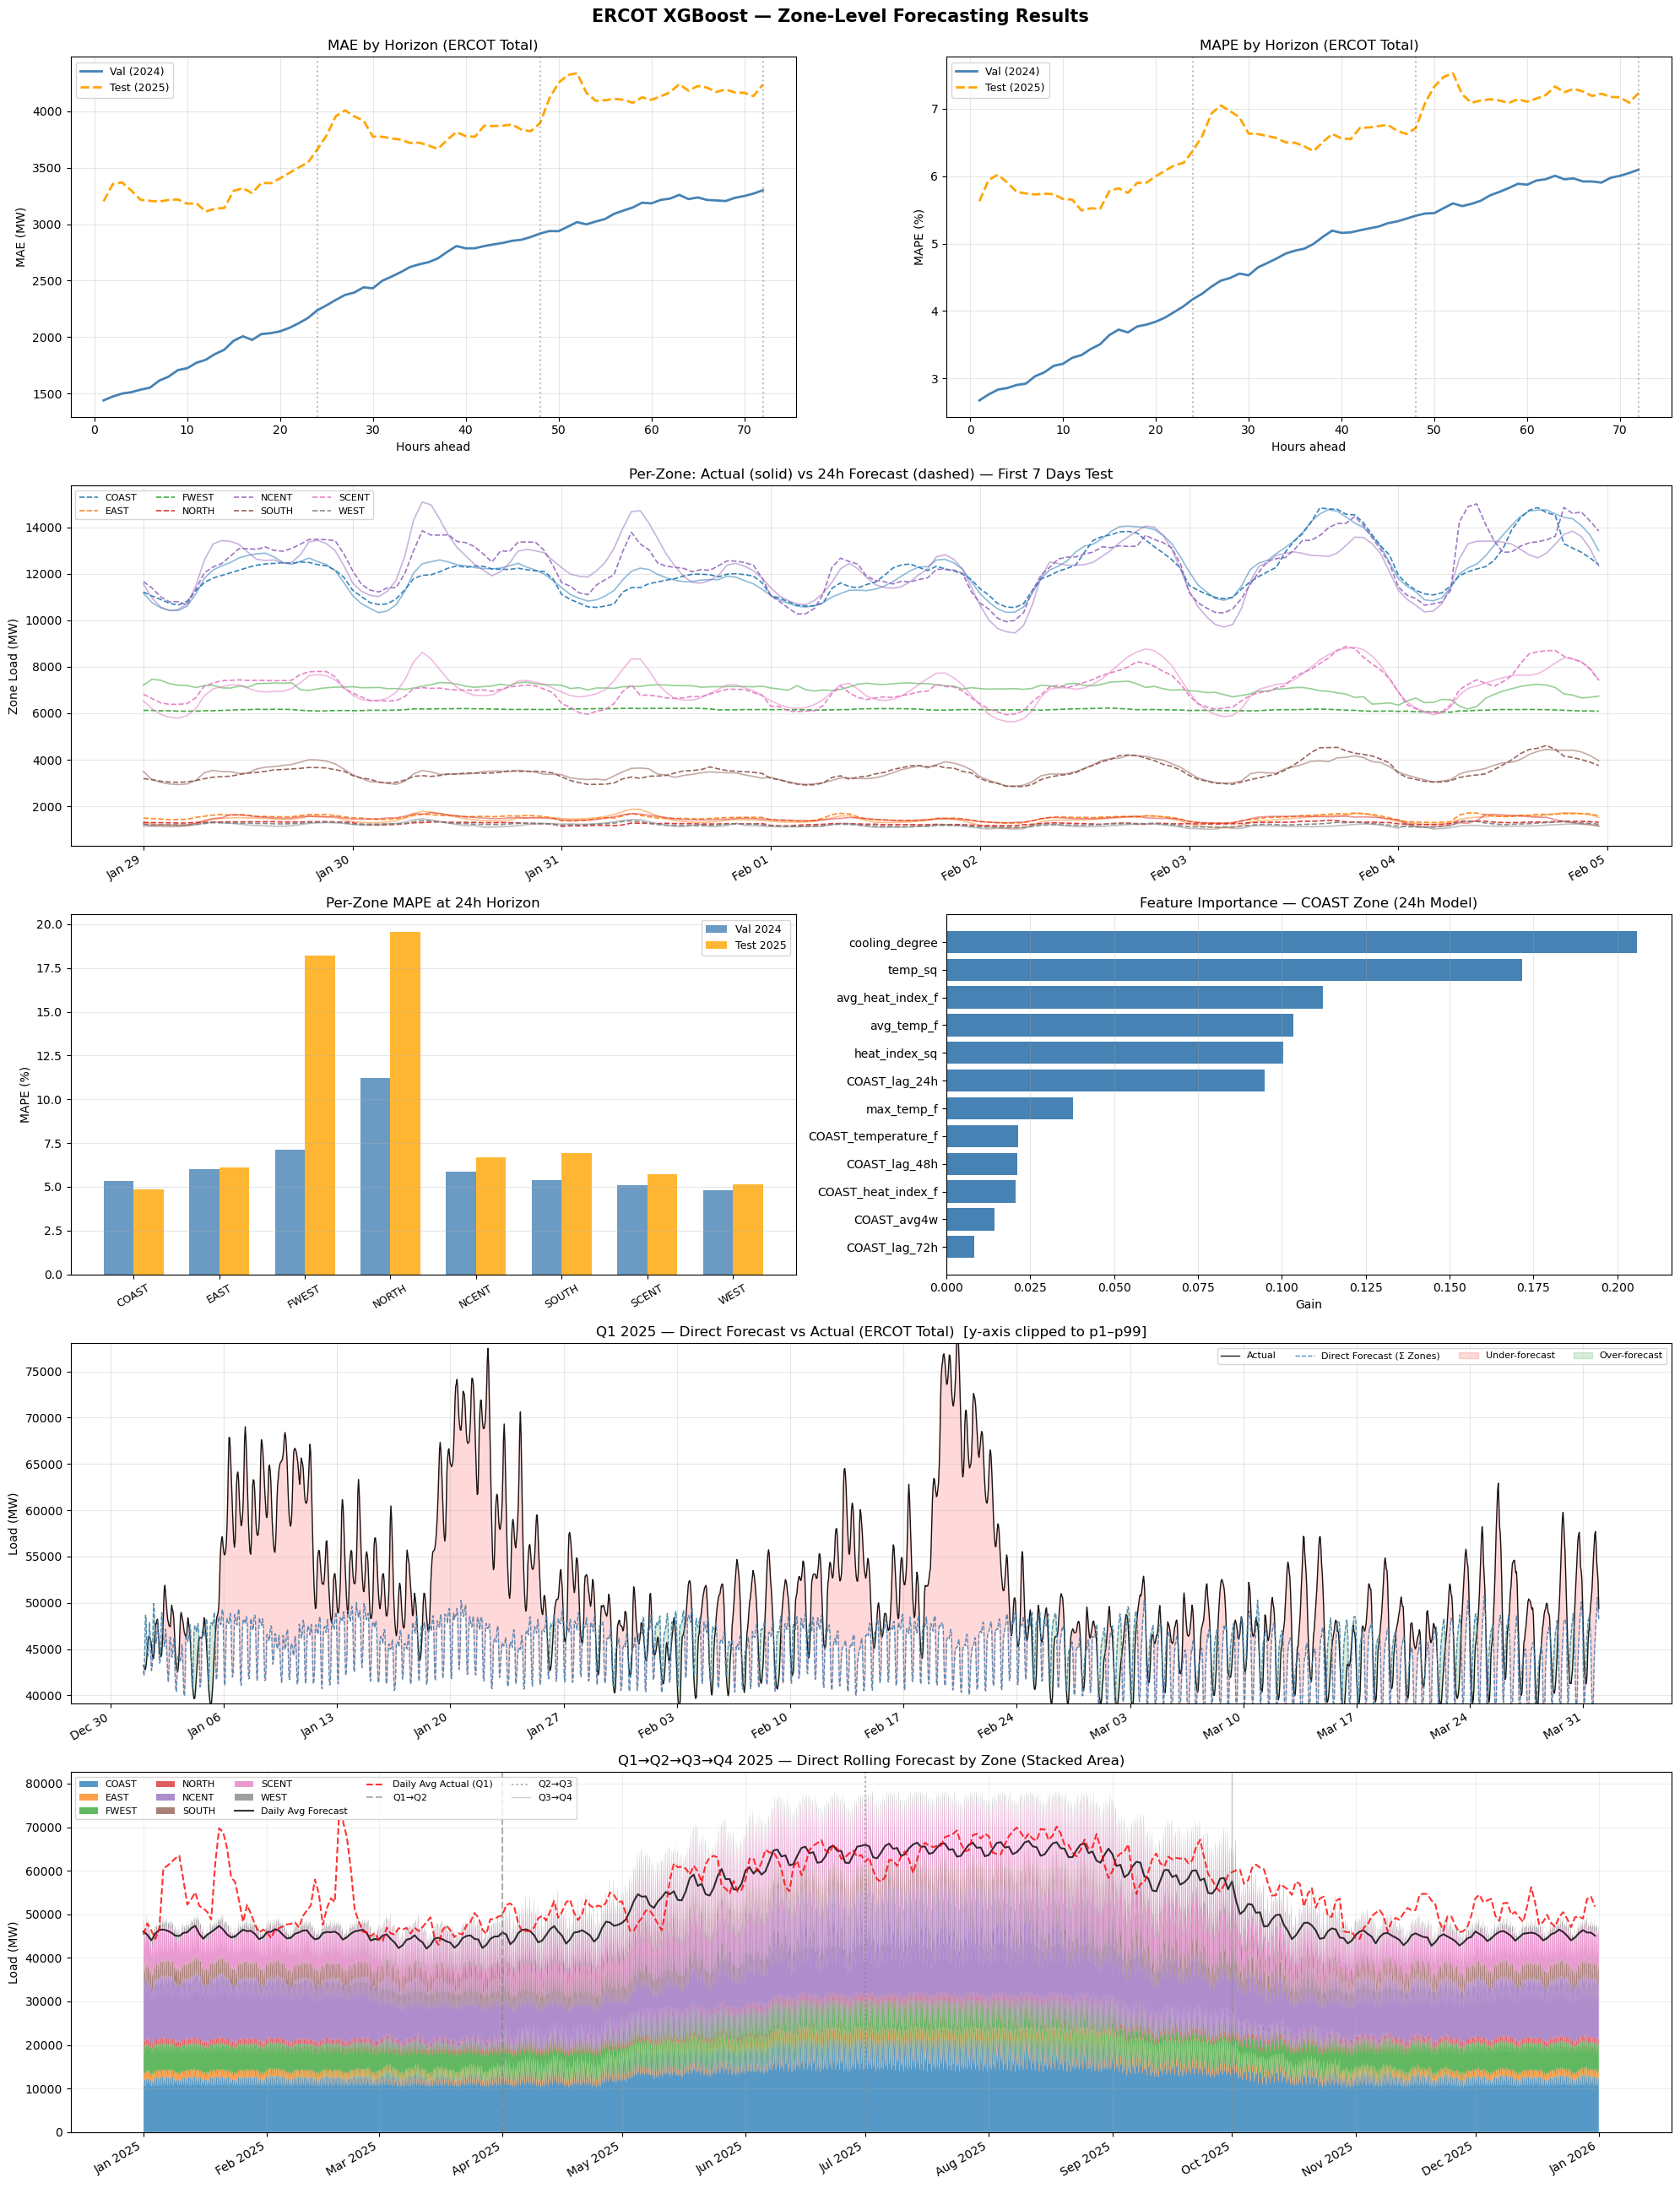

  Saved: xgb_zone_results.png

  DONE — Output files:
    xgb_metrics_by_horizon.csv          MAE/RMSE/MAPE per horizon
    xgb_fullyear_direct_forecast.csv    Q1+Q2+Q3+Q4 zone + total (direct rolling)
    xgb_zone_results.png                Full results plot


In [13]:
# ══════════════════════════════════════════════════════════════
# 10. PLOTS
# ══════════════════════════════════════════════════════════════

print("\n[5/5] Generating plots...")

ZONE_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728',
               '#9467bd','#8c564b','#e377c2','#7f7f7f']

fig = plt.figure(figsize=(20, 26))
fig.suptitle('ERCOT XGBoost — Zone-Level Forecasting Results',
             fontsize=15, fontweight='bold', y=0.995)

# ── R1: MAE / MAPE by horizon ─────────────────────────────────
ax1 = fig.add_subplot(5, 2, 1)
ax1.plot(HORIZONS, val_mae,       label='Val (2024)',  color='steelblue', lw=2)
ax1.plot(HORIZONS, test_mae,      label='Test (2025)', color='orange',    lw=2, ls='--')
for v in [24, 48, 72]: ax1.axvline(v, color='gray', ls=':', alpha=0.5)
ax1.set_title('MAE by Horizon (ERCOT Total)'); ax1.set_ylabel('MAE (MW)')
ax1.set_xlabel('Hours ahead'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(5, 2, 2)
ax2.plot(HORIZONS, val_mape_list,  label='Val (2024)',  color='steelblue', lw=2)
ax2.plot(HORIZONS, test_mape_list, label='Test (2025)', color='orange',    lw=2, ls='--')
for v in [24, 48, 72]: ax2.axvline(v, color='gray', ls=':', alpha=0.5)
ax2.set_title('MAPE by Horizon (ERCOT Total)'); ax2.set_ylabel('MAPE (%)')
ax2.set_xlabel('Hours ahead'); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# ── R2: Per-zone actual vs predicted (24h, first 7 days test) ─
ax3 = fig.add_subplot(5, 1, 2)
PLOT_START = 672   # skip first 4 weeks where lag_672h is NaN
PLOT_ROWS  = 7 * 24
for z, color in zip(ZONES, ZONE_COLORS):
    feats    = get_features(z, test)
    chunk    = test.iloc[PLOT_START : PLOT_START + PLOT_ROWS].copy()
    actual   = test.iloc[PLOT_START + 24 : PLOT_START + PLOT_ROWS + 24][f'{z}_load_mw'].values
    # drop any rows where features are NaN
    valid    = chunk[feats].notna().all(axis=1)
    chunk    = chunk[valid]
    actual   = actual[:len(chunk)]
    if len(chunk) == 0:
        continue
    pred = models[z][24].predict(chunk[feats])
    ax3.plot(chunk['datetime'], actual,  color=color, lw=1.2, alpha=0.5)
    ax3.plot(chunk['datetime'], pred,    color=color, lw=1.2, ls='--', alpha=0.9, label=z)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax3.set_title('Per-Zone: Actual (solid) vs 24h Forecast (dashed) — First 7 Days Test')
ax3.set_ylabel('Zone Load (MW)'); ax3.legend(fontsize=8, ncol=4); ax3.grid(True, alpha=0.3)

# ── R3: Per-zone MAPE bar (val vs test, h=24) ─────────────────
ax4 = fig.add_subplot(5, 2, 5)
x = np.arange(len(ZONES)); w = 0.35
ax4.bar(x - w/2, [val_zone_mape.get(z, 0)  for z in ZONES], w,
        label='Val 2024',  color='steelblue', alpha=0.8)
ax4.bar(x + w/2, [test_zone_mape.get(z, 0) for z in ZONES], w,
        label='Test 2025', color='orange',    alpha=0.8)
ax4.set_xticks(x); ax4.set_xticklabels(ZONES, rotation=30, fontsize=9)
ax4.set_title('Per-Zone MAPE at 24h Horizon')
ax4.set_ylabel('MAPE (%)'); ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, axis='y')

# ── R3: Feature importance — COAST (representative) ──────────
ax5 = fig.add_subplot(5, 2, 6)
top = imp_by_zone['COAST'].head(12)
ax5.barh(top['feature'][::-1], top['importance'][::-1], color='steelblue')
ax5.set_title('Feature Importance — COAST Zone (24h Model)')
ax5.set_xlabel('Gain'); ax5.grid(True, alpha=0.3, axis='x')

# ── R4: Q1 direct ERCOT total vs actual ──────────────────────
# Split into two panels: forecast comparison + residual error
ax6 = fig.add_subplot(5, 1, 4)
if len(common_q1) > 0:
    act_vals  = test_total[common_q1]
    fore_vals = direct_total_q1[common_q1]
    residuals = act_vals - fore_vals

    ax6.plot(act_vals.index,  act_vals.values,  color='black',     lw=1.0, label='Actual', alpha=0.9)
    ax6.plot(fore_vals.index, fore_vals.values, color='steelblue', lw=1.0, ls='--', label='Direct Forecast (Σ Zones)', alpha=0.9)
    # Shade error region
    ax6.fill_between(act_vals.index, act_vals.values, fore_vals.values,
                     where=(act_vals.values > fore_vals.values),
                     alpha=0.15, color='red',   label='Under-forecast')
    ax6.fill_between(act_vals.index, act_vals.values, fore_vals.values,
                     where=(act_vals.values < fore_vals.values),
                     alpha=0.15, color='green', label='Over-forecast')
    # Clip y-axis: show 5th–99th percentile of actuals to avoid spike distortion
    lo = np.percentile(act_vals.values, 1)
    hi = np.percentile(act_vals.values, 99) * 1.05
    ax6.set_ylim(lo, hi)
else:
    ax6.text(0.5, 0.5, 'No Q1 actuals available', transform=ax6.transAxes, ha='center')
ax6.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax6.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax6.set_title('Q1 2025 — Direct Forecast vs Actual (ERCOT Total)  [y-axis clipped to p1–p99]')
ax6.set_ylabel('Load (MW)'); ax6.legend(fontsize=8, ncol=4); ax6.grid(True, alpha=0.3)

# ── R5: Stacked area — full year direct rolling by zone ───────
ax7 = fig.add_subplot(5, 1, 5)
plot_idx   = direct_total_all.index
dir_arrays = np.array([
    dir_zone_all[z].reindex(plot_idx).fillna(0).values
    for z in ZONES
])
ax7.stackplot(plot_idx, dir_arrays, labels=ZONES, colors=ZONE_COLORS, alpha=0.75)
# Overlay daily smoothed total so seasonal shape is visible without spike distortion
daily_smooth = direct_total_all.resample('D').mean()
ax7.plot(daily_smooth.index, daily_smooth.values,
         color='black', lw=1.5, label='Daily Avg Forecast', alpha=0.8)
# Overlay actual daily avg where available
if len(test_in_fc := test_total.index.intersection(plot_idx)) > 0:
    actual_daily = test_total[test_in_fc].resample('D').mean()
    ax7.plot(actual_daily.index, actual_daily.values,
             color='red', lw=1.5, ls='--', label='Daily Avg Actual (Q1)', alpha=0.8)
ax7.axvline(Q2_START, color='gray', ls='--', lw=1.5, alpha=0.6, label='Q1→Q2')
ax7.axvline(Q3_START, color='gray', ls=':',  lw=1.5, alpha=0.6, label='Q2→Q3')
ax7.axvline(Q4_START, color='gray', ls='-',  lw=1.0, alpha=0.4, label='Q3→Q4')
ax7.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax7.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax7.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax7.set_title('Q1→Q2→Q3→Q4 2025 — Direct Rolling Forecast by Zone (Stacked Area)')
ax7.set_ylabel('Load (MW)')
ax7.legend(fontsize=8, loc='upper left', ncol=5)
ax7.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('xgb_zone_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: xgb_zone_results.png")

print("\n" + "=" * 62)
print("  DONE — Output files:")
print("    xgb_metrics_by_horizon.csv          MAE/RMSE/MAPE per horizon")
print("    xgb_fullyear_direct_forecast.csv    Q1+Q2+Q3+Q4 zone + total (direct rolling)")
print("    xgb_zone_results.png                Full results plot")
print("=" * 62)